In [1]:
%load_ext autoreload
%autoreload 2

%gui qt

ERROR:root:libGL.so.1: cannot open shared object file: No such file or directory


In [2]:
os.getcwd()

NameError: name 'os' is not defined

In [ ]:
import os
import sys
import importlib
gui_source_dir = os.path.expanduser("/root/vast/joshua/lucid_lite")
# josh_source_dir = os.path.expanduser("~/Documents/talmolab/repos/lucid_lite")

# add folders to Python's system path so it can find local imports
if gui_source_dir not in sys.path:
    sys.path.insert(0, gui_source_dir)
    # sys.path.insert(0, josh_source_dir)

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import numpy as np
import pandas as pd
import sleap_io as sio

# from PySide6.QtGui import QImage


# import gui_source.main
# import gui_source.colors

from josh_source import epipolar
from josh_source import geometry

ImportError: libGL.so.1: cannot open shared object file: No such file or directory

In [3]:
app, window = main.main(
    [
        "main.py",                                                          
        "/Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420_small"
    ]
)
# define globals
session = window.session

SKEL = session.skeleton
TRACK_COLOR_MAP = {track: colors.get_track_color(n) for n, track in enumerate(session.tracks)}
CAMERAS = {camera.name: camera for camera in session.cameras}

NODE_NAMES = [
    "Nose",
    "Ear_R",
    "Ear_L",
    "TTI",
    "TailTip",
    "Head",
    "Trunk",
    "Tail_0",
    "Tail_1",
    "Tail_2",
    "Shoulder_left",
    "Shoulder_right",
    "Haunch_left",
    "Haunch_right",
    "Neck"
]

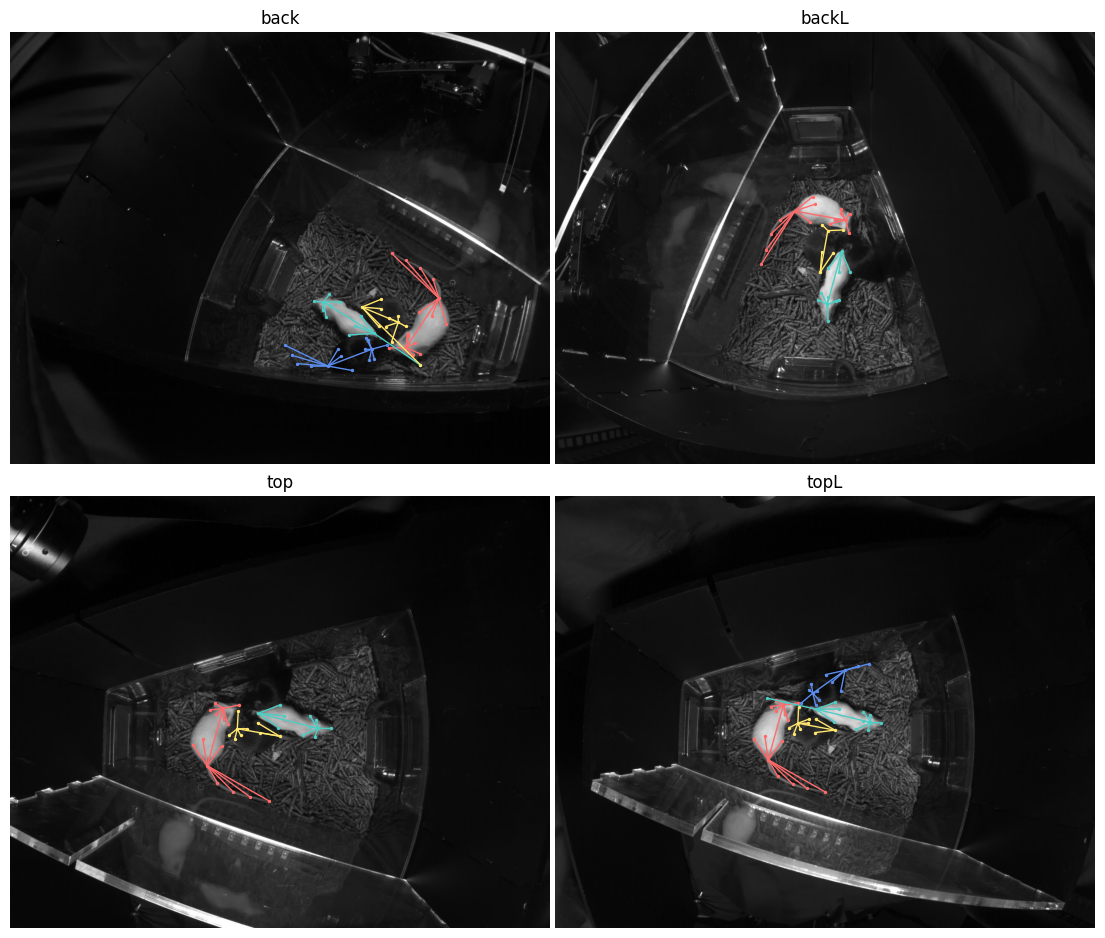

In [5]:
def frame_df(frame_idx = None):
    if frame_idx is None:
        fg = session.frame_group(window._current_frame)
    else:
        fg = session.frame_group(frame_idx)
    rows = []
    for cam, insts in fg.instances.items():
        for inst in insts:
            rows.append({
                'cam': cam,
                'points': inst.points,
                'track_idx': inst.track_idx,
                "track": (session.tracks[inst.track_idx]
                        if inst.track_idx is not None else None),
                "identity_id": session.get_identity_id_for_track(
                    window._current_frame, cam, inst.track_idx),
                "type": inst.type,
                "score": inst.score,
                "n_visible": sum(p is not None for p in inst.points),
            })
    return pd.DataFrame(rows)


df = frame_df()
epipolar.display_cams(
    window,
    ['back', 'backL', 'top', 'topL'],
    df,
    SKEL,
    TRACK_COLOR_MAP,
    (2, 2))

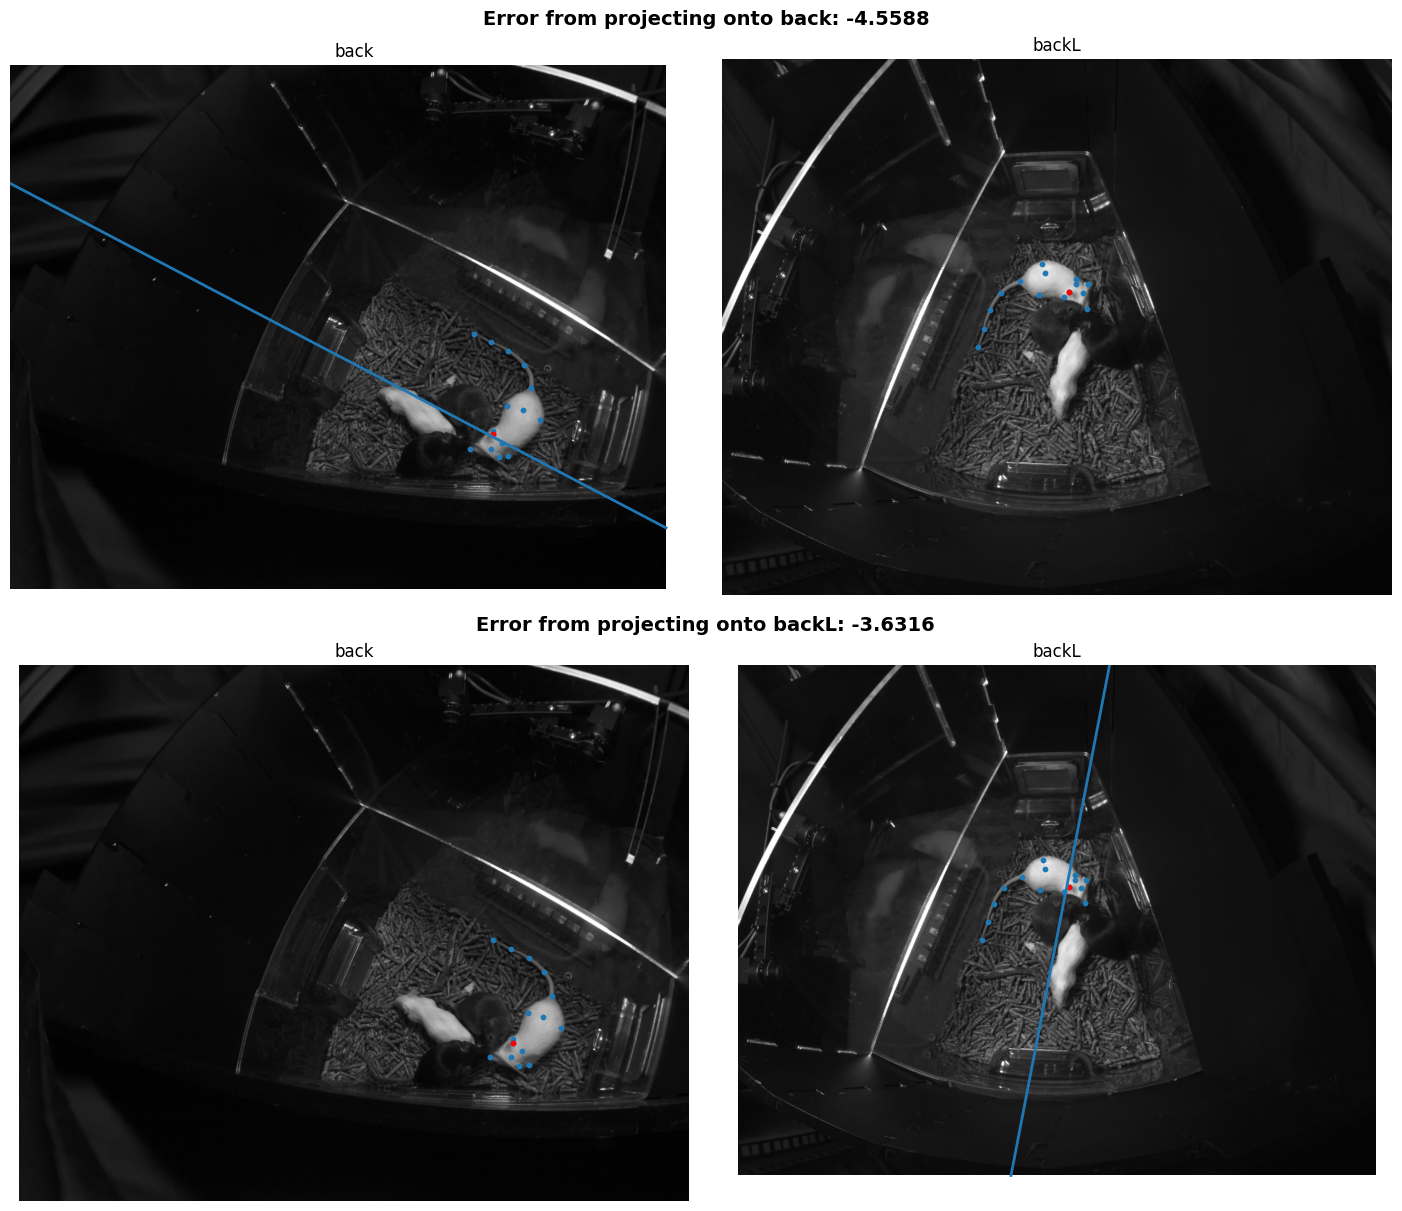

In [145]:
epipolar.draw_epline_single_point(window, CAMERAS, ['back', 'backL'], df, node_idx=1)
print()

sum image 1 error: 49.922
sum image 2 error: 42.448


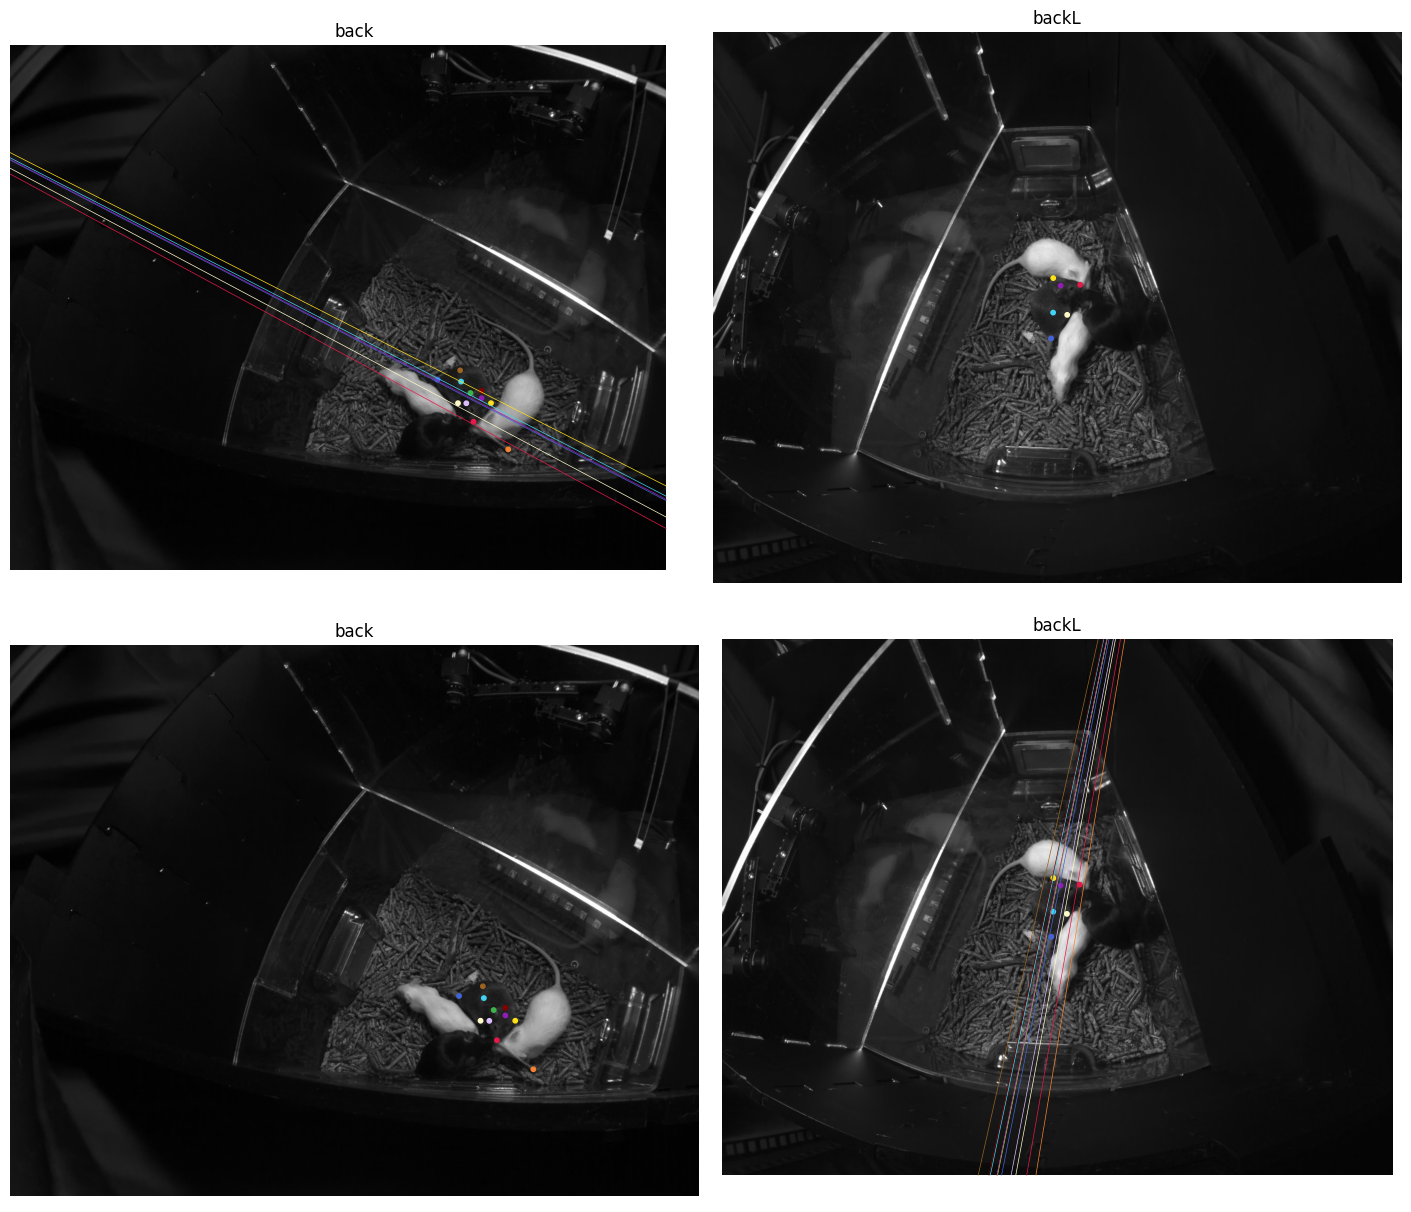

: 

In [ ]:
importlib.reload(epipolar)

error = epipolar.draw_eplines_whole_instance(window, CAMERAS, ['back', 'backL'], df, track_idx=2)

print(f'sum image 1 error: {np.nansum(np.abs(error[0])):.3f}')
print(f'sum image 2 error: {np.nansum(np.abs(error[1])):.3f}')

In [163]:
error[0]

array([-3.37567805, -2.59136098, -5.52396103, -8.82185336,         nan,
       -3.69944269, -4.9338714 ,         nan,         nan,         nan,
       -1.58497723, -2.57531201, -7.23947265, -2.15016256, -2.81023159])

In [160]:
pt = df.query('cam == "backL" and track_idx == 1')['points'].iloc[0]
pt = np.asarray([p if p is not None else (np.nan, np.nan) for p in pt])
pt
# geometry.homogenize(pt)

array([[646.5222168 , 686.11169434],
       [622.74639893, 634.18786621],
       [664.69116211, 638.21411133],
       [678.83361816, 520.16571045],
       [         nan,          nan],
       [644.62963867, 646.41137695],
       [672.71124268, 568.0300293 ],
       [         nan,          nan],
       [         nan,          nan],
       [         nan,          nan],
       [672.91101074, 634.26489258],
       [630.54876709, 618.28271484],
       [698.7088623 , 568.17260742],
       [646.89910889, 560.0145874 ],
       [646.96942139, 628.33227539]])